In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ModuleNotFoundError: No module named 'sklearn'

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.1 MB 2.3 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.3 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.2 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.1 MB 2.2 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 2.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 2.3 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 2.3 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.1 MB 2.3 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Práctica 5 – Linear Models + Correlation

En esta práctica se construye un modelo de regresión lineal para analizar la relación entre la producción de café y el consumo doméstico.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Carga del dataset

Se carga el dataset previamente limpiado para realizar el análisis de regresión lineal.

In [4]:
df = pd.read_csv("../dataset/coffee_cleaned.csv")
df.head()

,country,year,arabica_production,bean_exports,bean_imports,beginning_stocks,domestic_consumption,ending_stocks,exports,imports,...,production,roast_and_ground_exports,roast_and_ground_imports,robusta_production,rstground_dom_consum,soluble_dom_cons,soluble_exports,soluble_imports,total_distribution,total_supply
0,Albania,1960,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Albania,1961,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Albania,1962,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Albania,1963,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Albania,1964,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Selección de variables

Se selecciona la variable *production* como variable independiente (X) y *domestic_consumption* como variable dependiente (y), con el objetivo de analizar la relación entre ambas.

In [5]:
X = df[['production']]   # variable independiente
y = df['domestic_consumption']  # variable dependiente

## Modelo de regresión lineal

Se construye un modelo de regresión lineal utilizando la librería scikit-learn para analizar la relación entre la producción y el consumo de café.

In [6]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predicciones

El modelo genera valores predichos de consumo a partir de los datos de producción, lo que permite evaluar su desempeño.

In [7]:
y_pred = model.predict(X)

## Coeficiente de determinación (R²)

El coeficiente de determinación (R²) se utiliza para medir qué tan bien el modelo explica la variabilidad de los datos.

Un valor cercano a 1 indica una buena relación, mientras que un valor cercano a 0 indica una relación débil.

In [8]:
r2 = r2_score(y, y_pred)
r2

0.14402670600211231

## Coeficiente de determinación (R²)

El valor de R² obtenido fue de 0.144, lo que indica que el modelo explica aproximadamente el 14.4% de la variabilidad del consumo de café.

Este valor sugiere que la relación entre la producción y el consumo es débil, por lo que la producción no es un buen predictor del consumo en este dataset.

Interpretación del R²
cercano a 1 → buena relación
cercano a 0 → relación débil

## Visualización del modelo

Se genera una gráfica de dispersión junto con la línea de regresión para visualizar la relación entre la producción y el consumo de café.

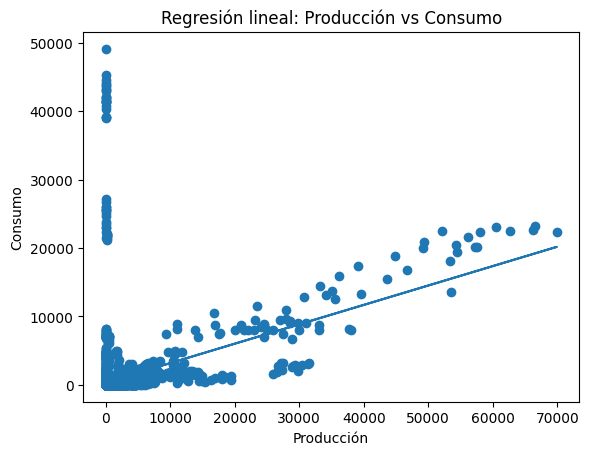

In [9]:
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Regresión lineal: Producción vs Consumo")
plt.xlabel("Producción")
plt.ylabel("Consumo")
plt.show()

## Correlación

Se calcula la correlación entre la producción y el consumo para medir la fuerza de la relación entre ambas variables.

In [10]:
df[['production', 'domestic_consumption']].corr()

,production,domestic_consumption
production,1.000000,0.379509
domestic_consumption,0.379509,1.000000


## Conclusiones

El modelo de regresión lineal muestra que existe una relación débil entre la producción y el consumo de café.

Esto indica que otros factores, además de la producción, influyen en el consumo de café en los diferentes países.

El modelo no es suficientemente fuerte para realizar predicciones precisas, por lo que se podrían explorar otras variables o modelos más complejos en futuras prácticas.